# Libraries

In [31]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.metrics import root_mean_squared_error, r2_score

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Retrieving Dataframe

In [32]:
df = pd.read_csv("../data/df_model.csv")
print(df.shape)
display(df.head(3))

(5000, 19)


,period,subba,subba-name,parent,parent-name,timezone,value,value-units,DATE,STATION,NAME,AWND,PRCP,TAVG,TMAX,TMIN,Year,Month,Weekday
0,2022-04-01,PS,Public Service Electric & Gas of New Jersey zo...,PJM,"PJM Interconnection, LLC",Arizona,100418.0,megawatthours,2022-04-01,US1NJHN0019,"LEBANON 3.2 SW, NJ US",17.22,0.24,57.0,70.0,52.0,2022,4,Friday
1,2022-04-02,PS,Public Service Electric & Gas of New Jersey zo...,PJM,"PJM Interconnection, LLC",Pacific,90501.0,megawatthours,2022-04-02,US1NJHN0019,"LEBANON 3.2 SW, NJ US",11.41,0.01,46.0,58.0,34.0,2022,4,Saturday
2,2022-04-02,PS,Public Service Electric & Gas of New Jersey zo...,PJM,"PJM Interconnection, LLC",Mountain,90686.0,megawatthours,2022-04-02,US1NJHN0019,"LEBANON 3.2 SW, NJ US",11.41,0.01,46.0,58.0,34.0,2022,4,Saturday


In [33]:
df = pd.get_dummies(df, columns=["Weekday"])

## Models

In [34]:
def model_results(y_test, y_pred, name):

    print("\nR2:", r2_score(y_test, y_pred))
    print("RMSE:", root_mean_squared_error(y_test, y_pred))

    # Plot
    plt.figure(figsize=(8,6))
    plt.scatter(y_test, y_pred)
    
    # prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle='--')
    
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{name}")
    
    plt.show()

In [35]:
df.columns

Index(['period', 'subba', 'subba-name', 'parent', 'parent-name', 'timezone',
       'value', 'value-units', 'DATE', 'STATION', 'NAME', 'AWND', 'PRCP',
       'TAVG', 'TMAX', 'TMIN', 'Year', 'Month', 'Weekday_Friday',
       'Weekday_Monday', 'Weekday_Saturday', 'Weekday_Sunday',
       'Weekday_Thursday', 'Weekday_Tuesday', 'Weekday_Wednesday'],
      dtype='object')

In [39]:
# Test features
feats = ['demand' ,'TMIN', 'TAVG', 'TMAX', 'PRCP', 'Month', 'Weekday_Friday',
       'Weekday_Monday', 'Weekday_Saturday', 'Weekday_Sunday',
       'Weekday_Thursday', 'Weekday_Tuesday', 'Weekday_Wednesday']

model_df = df[feats]

np.random.seed(615)

X = model_df.drop("demand", axis=1)
y = model_df["demand"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [37]:
'''
param_grid = {
    'n_estimators': [100, 200, 400],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(RandomForestRegressor(), param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)
'''

'\nparam_grid = {\n    \'n_estimators\': [100, 200, 400],\n    \'max_depth\': [None, 10, 20],\n    \'min_samples_split\': [2, 5],\n    \'min_samples_leaf\': [1, 2],\n    \'bootstrap\': [True, False]\n}\n\ngrid_search = GridSearchCV(RandomForestRegressor(), param_grid=param_grid, cv=5)\ngrid_search.fit(X_train, y_train)\n\nprint("Best Parameters:", grid_search.best_params_)\nprint("Best Estimator:", grid_search.best_estimator_)\n'


R2: 0.9815785969637847
RMSE: 2967.5847825001383


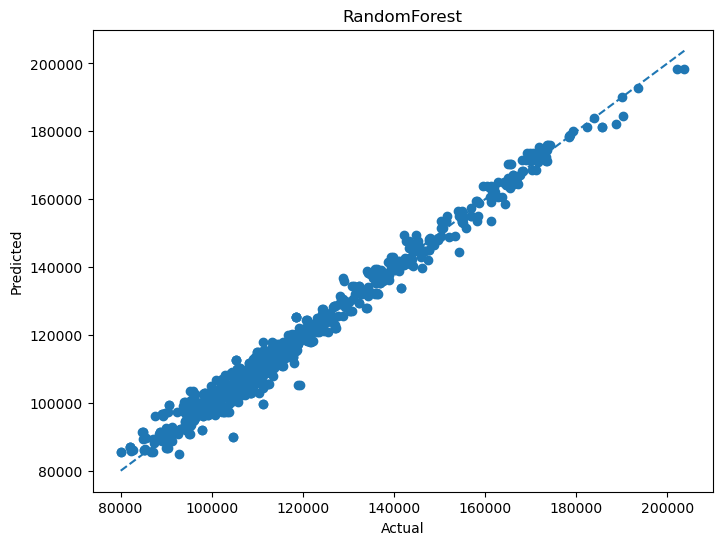

In [40]:
model = RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=400)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

model_results(y_test, y_pred, 'RandomForest')